In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../data/raw/train.csv")
print("Load data successfully!")

Load data successfully!


In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

#create DataFrame to display and sort the missing values
missing_table = pd.DataFrame({'missing': missing, 'pct': missing_pct})
missing_table.sort_values('pct', ascending=False)

,missing,pct
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
...,...,...
MoSold,0,0.000000
YrSold,0,0.000000
SaleType,0,0.000000
SaleCondition,0,0.000000


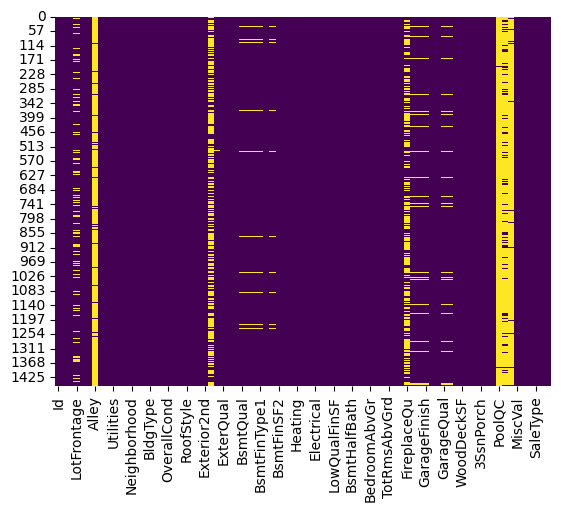

In [4]:
# Paint a heatmap to visualize the missing values
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

In [ ]:

# Function to handle missing values in the dataset
def handle_missing(df):
    # Copy to avoid modifying the original DataFrame
    df_clean = df.copy()
    
    # 1. Group Categorical "NA = None" -> Fill by 'None'
    # According to the data description, these column are none cause house doesn't have this feature
    na_means_none = [
        'PoolQC', 'Alley', 'Fence', 'FireplaceQu', 
        'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
        'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
        'MiscFeature'
    ]
    for col in na_means_none:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna("None")
            
    # 2. Handle numeric columns related to Garage (GarageYrBlt)
    # If there is no garage, fill the year with 0 (or a marker value)
    if 'GarageYrBlt' in df_clean.columns:
        df_clean['GarageYrBlt'] = df_clean['GarageYrBlt'].fillna(0)
        
    #Fill other numeric columns that are related to Garage with 0
    numeric_zeros = ['GarageCars', 'GarageArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']
    for col in numeric_zeros:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna(0)

    # Create new binary features to indicate the presence of certain features
    # For example, if a house has a pool, the 'has_pool' column will be 1, otherwise 0
    if 'PoolQC' in df_clean.columns:
        df_clean['has_pool'] = df_clean['PoolQC'].apply(lambda x: 0 if x == "None" else 1)
    if 'MiscFeature' in df_clean.columns:
        df_clean['has_misc'] = df_clean['MiscFeature'].apply(lambda x: 0 if x == "None" else 1)

    # 4. Nhóm "Thiếu thật" với tỷ lệ nhỏ -> Điền bằng Median (Số) hoặc Mode (Chữ)
    # Ví dụ: LotFrontage (Số) -> Median
    if 'LotFrontage' in df_clean.columns:
        df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(df_clean['LotFrontage'].median())
        
    # Ví dụ: Electrical (Chữ) -> Mode (Giá trị xuất hiện nhiều nhất)
    if 'Electrical' in df_clean.columns:
        df_clean['Electrical'] = df_clean['Electrical'].fillna(df_clean['Electrical'].mode()[0])
        
    # Automatically fill other missing values based on their data type
    for col in df_clean.columns:
        if df_clean[col].isnull().sum() > 0:
            if df_clean[col].dtype == 'object':
                df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
            else:
                df_clean[col] = df_clean[col].fillna(df_clean[col].median())
                
    return df_clean